In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
from datetime import datetime


import sys
import os

In [2]:
# MAGIA (não mexer mt pfv)
def show_args(func):
    def wrapper(*args, **kwargs):
        arg_list = []

        # Prepare argument list
        for name, value in zip(func.__code__.co_varnames, args):
            if isinstance(value, pd.DataFrame):
                arg_list.append(f"{name}: DataFrame ({value.shape})")
            else:
                arg_list.append(f"{name}: {value}")
        for k, v in kwargs.items():
            if isinstance(v, pd.DataFrame):
                arg_list.append(f"{k}: DataFrame ({v.shape})")
            else:
                arg_list.append(f"{k}: {v}")

        print(f"Executando <{func.__name__}>\n({'\\n'.join(arg_list)})")

        # Measure execution time
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()

        print(f"Tempo de execução: {end - start:.6f} segundos\n")
        return result
    return wrapper

In [3]:
from pathlib import Path
import pandas as pd

@show_args
def csvs_to_parquet(input_folder, output_folder):
    input_path = Path(input_folder)
    output_path = Path(output_folder)
    output_path.mkdir(parents=True, exist_ok=True)

    for csv_file in input_path.glob("*.csv"):
        try:
            df = pd.read_csv(csv_file, encoding="utf-8")
        except UnicodeDecodeError:
            df = pd.read_csv(csv_file, encoding="latin1")

        parquet_file = output_path / csv_file.with_suffix(".parquet").name
        df.to_parquet(parquet_file, index=False)



In [4]:
#csvs_to_parquet("../data/data/refined/csvs", "../data/data/refined/parquets")

In [5]:
articles_raw = pd.read_parquet('../data/data/refined/parquets/article.parquet').rename(columns={
    'eid': 'art_id',
    'subtype description': 'art_subtype',
    'title': 'art_title',
    'published date': 'art_published_date',
    'cited by count': 'art_citations',
    'source id' : 'art_source',
    'aggregation type' : 'art_source_type'
})[['art_id', 'art_subtype', 'art_title', 'art_published_date', 'art_citations', 'art_source', 'art_source_type']] # B

scores_raw = pd.read_parquet('../data/data/refined/parquets/CiteScore_2024_annual_values.parquet').rename(columns={
    'Scopus Source ID' : 'art_source',
    'Title' : 'src_title',
    'Citation Count' : 'src_citation_count',
    'CiteScore' : 'src_citescore',
    'Scopus Sub-Subject Area' : 'src_subject_area',
    'Percentile' : 'src_percentile',
    'RANK' : 'src_rank',
    'Rank Out Of' : 'src_rank_count',
    'Quartile' : 'src_quartile'
})[['art_source', 'src_title', 'src_citation_count', 'src_citescore', 'src_subject_area', 'src_percentile', 'src_rank', 'src_rank_count', 'src_quartile']]


authors_institutions_raw = pd.read_parquet('../data/data/refined/parquets/authors_institution.parquet').rename(columns={
    #eid,auid,creator,afid,dptid,organization,country,city
    'eid': 'art_id',
    'auid': 'aut_id',
    'creator': 'main_writer',
    'afid': 'ins_id',
    'dptid': 'dpt_id',
    'organization': 'ins_org',
    'country': 'ins_country',
    'city': 'ins_city'
})

institutions_raw = (pd.read_parquet('../data/data/refined/parquets/institutions.parquet').rename(columns={
        'Código Mantenedora': 'ins_maint_id',
        # 'Razão Social': 'ins_legal_name',
        # 'Município': 'ins_city',
        # 'UF': 'ins_state',
        # 'Tipo de Credenciamento': 'ins_modalidade',
        'Categoria': 'ins_category',
        # 'CI': 'ins_ci',
        # 'Ano CI': 'ins_ci_year',
        # 'CI-EaD': 'ins_ci_ead',
        # 'Ano CI-EaD': 'ins_ci_ead_year',
        # 'IGC': 'ins_igc',
        'afid': 'ins_id',
        # 'Ano IGC': 'ins_igc_year',
        'Situação da IES': 'ins_status',
        'Código IES': 'ins_code',
        'name': 'ins_name'
    })
    [['ins_maint_id', 'ins_category', 'ins_id', 'ins_status', 'ins_code', 'ins_name']]
)

#articles_authors_raw = pd.read_parquet('../data/data/refined/parquets/articles_author.parquet').rename(columns={
#    'eid': 'art_id',
#    'auid': 'aut_id',
#    'creator': 'main_writer'
#})[['art_id', 'aut_id', 'main_writer']]
#
authors_raw = pd.read_parquet('../data/data/refined/parquets/author.parquet').rename(columns={
    'auid': 'aut_id',
    'given name': 'aut_name',
    'surname': 'aut_surname',
    'indexed name': 'aut_indexed_name'
})[['aut_id', 'aut_name', 'aut_surname', 'aut_indexed_name']]

# departments_raw = pd.read_parquet('../data/data/refined/parquets/departments.parquet').rename(columns={
#     'afid' : 'ins_id',
#     'dptid': 'dpt_id',
#     'organization': 'dpt_name',
#     'country' : 'dpt_country',
#     'city' : 'dpt_city'
# })[['ins_id', 'dpt_id', 'dpt_name', 'dpt_country', 'dpt_city']]

# articles_subject_areas_raw = pd.read_parquet('../data/data/refined/parquets/article_subject_areas.parquet').rename(columns={
#     'eid': 'art_id',
#     'subject area code': 'sub_id'
# })[['art_id', 'sub_id']] # A

subject_areas_raw = pd.read_parquet('../data/data/refined/parquets/subject_area.parquet')
subject_areas_raw.columns = ['sub_id', 'src_subject_area', 'src_subject_macro'] # A

# articles_institutions_raw = pd.read_parquet('../data/data/refined/parquets/articles_institution.parquet').rename(columns={
#     'eid': 'art_id',
#     'afid': 'ins_id',
#     'creator': 'main_writer',
#     'country': 'ins_country'
# })[['art_id', 'ins_id', 'main_writer', 'ins_country']]




In [6]:
main = (
articles_raw
    .merge(scores_raw, on='art_source', how='inner')
    .merge(authors_institutions_raw, on='art_id', how='inner')
    .merge(institutions_raw, on='ins_id', how='inner') # TODO: pegar as universidade restantes. (Left join para checar quais são, e colocar no institutions_raw)
    .merge(authors_raw, on='aut_id', how='inner')
    .merge(subject_areas_raw, on='src_subject_area', how='inner')
    #.merge(authors_raw, on='aut_id', how='inner')
    #.merge(institutions_raw, on='art_id', how='inner')
    # .merge(subjects_info, on='art_id', how='inner')
    # .merge(articles_raw, on='art_source', how='inner')
)

#articles_institutions_raw['ins_id'] = articles_institutions_raw['ins_id'].astype(str)
#institutions_raw['ins_id'] = institutions_raw['ins_id'].astype(str)
#departments_raw['ins_id'] = departments_raw['ins_id'].astype(str)
#main = main.merge(departments_info, on='ins_id', how='left')


In [7]:
institutions_raw['ins_id'].value_counts()

ins_id
60003597     31
60022378     31
60281103     21
60019608      8
60021699      8
             ..
118511108     1
118626976     1
101929885     1
106310222     1
131888906     1
Name: count, Length: 1159, dtype: int64

In [8]:
main.head()

,art_id,art_subtype,art_title,art_published_date,art_citations,art_source,art_source_type,src_title,src_citation_count,src_citescore,...,ins_maint_id,ins_category,ins_status,ins_code,ins_name,aut_name,aut_surname,aut_indexed_name,sub_id,src_subject_macro
0,2-s2.0-84951935294,Article,Body adiposity index performance in estimating...,2015-12-30,18.0,12653.0,Journal,Nutrition Journal,2502,6.7,...,15715,Publica,Ativa,55,Universidade de São Paulo,Giliane,Belarmino,Belarmino G.,2701,MEDI
1,2-s2.0-84951935294,Article,Body adiposity index performance in estimating...,2015-12-30,18.0,12653.0,Journal,Nutrition Journal,2502,6.7,...,15715,Publica,Ativa,55,Universidade de São Paulo,Lilian Mika,Horie,Horie L.M.,2701,MEDI
2,2-s2.0-84951935294,Article,Body adiposity index performance in estimating...,2015-12-30,18.0,12653.0,Journal,Nutrition Journal,2502,6.7,...,15715,Publica,Ativa,55,Universidade de São Paulo,Priscila Campos,Sala,Sala P.C.,2701,MEDI
3,2-s2.0-84951935294,Article,Body adiposity index performance in estimating...,2015-12-30,18.0,12653.0,Journal,Nutrition Journal,2502,6.7,...,15715,Publica,Ativa,55,Universidade de São Paulo,Raquel S.,Torrinhas,Torrinhas R.S.,2701,MEDI
4,2-s2.0-84951935294,Article,Body adiposity index performance in estimating...,2015-12-30,18.0,12653.0,Journal,Nutrition Journal,2502,6.7,...,15715,Publica,Ativa,55,Universidade de São Paulo,Dan L.,Waitzberg,Waitzberg D.L.,2701,MEDI


In [9]:
teste = main.head(6000)
teste.to_csv('teste.csv')

In [10]:
main.columns

Index(['art_id', 'art_subtype', 'art_title', 'art_published_date',
       'art_citations', 'art_source', 'art_source_type', 'src_title',
       'src_citation_count', 'src_citescore', 'src_subject_area',
       'src_percentile', 'src_rank', 'src_rank_count', 'src_quartile',
       'aut_id', 'main_writer', 'ins_id', 'dpt_id', 'ins_org', 'ins_country',
       'ins_city', 'ins_maint_id', 'ins_category', 'ins_status', 'ins_code',
       'ins_name', 'aut_name', 'aut_surname', 'aut_indexed_name', 'sub_id',
       'src_subject_macro'],
      dtype='object')

In [11]:
ranking = main[['art_id', 'art_subtype', 'art_published_date', 'src_subject_area', 'src_subject_macro', 'src_percentile', 'ins_maint_id', 'ins_name', 'ins_category', 'ins_country', 'aut_id']]
institution = main[['ins_maint_id', 'ins_name', 'ins_category', 'ins_status']].drop_duplicates(subset=['ins_maint_id'])


print(institution.shape)

(571, 4)


In [12]:
print(institution[(institution['ins_name'] == 'Universidade Federal Fluminense')])

    ins_maint_id                         ins_name ins_category ins_status
15         15589  Universidade Federal Fluminense      Publica      Ativa


In [13]:
institution.head()

,ins_maint_id,ins_name,ins_category,ins_status
0,15715,Universidade de São Paulo,Publica,Ativa
15,15589,Universidade Federal Fluminense,Publica,Ativa
19,14678,Universidade Federal de Santa Maria,Publica,Ativa
21,15515,Universidade Federal de Minas Gerais,Publica,Ativa
25,283,Universidade de Pernambuco,Publica,Ativa


In [14]:
ranking.head()

,art_id,art_subtype,art_published_date,src_subject_area,src_subject_macro,src_percentile,ins_maint_id,ins_name,ins_category,ins_country,aut_id
0,2-s2.0-84951935294,Article,2015-12-30,Medicine (miscellaneous),MEDI,83,15715,Universidade de São Paulo,Publica,Brazil,56862304200
1,2-s2.0-84951935294,Article,2015-12-30,Medicine (miscellaneous),MEDI,83,15715,Universidade de São Paulo,Publica,Brazil,16241649700
2,2-s2.0-84951935294,Article,2015-12-30,Medicine (miscellaneous),MEDI,83,15715,Universidade de São Paulo,Publica,Brazil,54400149800
3,2-s2.0-84951935294,Article,2015-12-30,Medicine (miscellaneous),MEDI,83,15715,Universidade de São Paulo,Publica,Brazil,6506627898
4,2-s2.0-84951935294,Article,2015-12-30,Medicine (miscellaneous),MEDI,83,15715,Universidade de São Paulo,Publica,Brazil,7006460075


In [15]:
ranking_article = ranking[(ranking['art_subtype'] == 'Article')]
#ranking_article['DI_value'] = (ranking_article['src_percentile'] / ranking_article.groupby('art_id')['aut_id'].transform('count'))
ranking_article['DI_value'] = (1/ ranking_article.groupby('art_id')['aut_id'].transform('count'))

C:\Users\dtaka\AppData\Local\Temp\ipykernel_23720\3896164750.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ranking_article['DI_value'] = (1/ ranking_article.groupby('art_id')['aut_id'].transform('count'))


In [16]:
ranking.head(100000).to_csv('rankings.csv', index=False)

In [17]:
# --- subject-level ---
sub_sums = ranking_article.groupby(['ins_maint_id', 'src_subject_area'])['DI_value'].sum()
pivoted_area = sub_sums.unstack(fill_value=0).reset_index()

di_table_subs = (
    institution
    .merge(pivoted_area, on='ins_maint_id', how='left')
    .fillna(0)
)

# --- macro-level (completely separate) ---
macro_sums = ranking_article.groupby(['ins_maint_id', 'src_subject_macro'])['DI_value'].sum()
pivoted_macro = macro_sums.unstack(fill_value=0).reset_index()

di_table_macros = (
    institution
    .merge(pivoted_macro, on='ins_maint_id', how='left')
    .fillna(0)
)

In [18]:
print(sub_sums)

ins_maint_id  src_subject_area                
1             Accounting                          1.653968
              Acoustics and Ultrasonics           1.700000
              Advanced and Specialized Nursing    8.806466
              Aerospace Engineering               0.483333
              Aging                               1.118703
                                                    ...   
19572         Language and Linguistics            0.100000
              Linguistics and Language            0.100000
              Social Sciences (miscellaneous)     0.062500
19664         Economics and Econometrics          0.250000
              Marketing                           0.250000
Name: DI_value, Length: 57276, dtype: float64


In [19]:
di_table_subs.head()

,ins_maint_id,ins_name,ins_category,ins_status,Accounting,Acoustics and Ultrasonics,Advanced and Specialized Nursing,Aerospace Engineering,Aging,Agricultural and Biological Sciences (miscellaneous),...,Toxicology,Transplantation,Transportation,Urban Studies,Urology,Veterinary (miscellaneous),Virology,Visual Arts and Performing Arts,Waste Management and Disposal,Water Science and Technology
0,15715,Universidade de São Paulo,Publica,Ativa,76.715512,50.972030,116.697536,112.910437,71.094912,163.182917,...,475.374421,146.951700,59.560119,95.181238,300.493597,37.407609,259.908087,110.006667,349.917220,302.910083
1,15589,Universidade Federal Fluminense,Publica,Ativa,4.530952,3.944147,14.768098,9.496055,1.735570,12.808184,...,18.611943,2.676340,8.532143,15.422143,15.200977,3.444444,11.001322,18.190079,28.369088,32.355018
2,14678,Universidade Federal de Santa Maria,Publica,Ativa,11.936111,14.589649,21.796429,7.109444,4.122075,49.617079,...,136.715455,0.000000,3.198413,8.673926,3.036111,9.672312,21.108123,13.908333,71.595835,87.975061
3,15515,Universidade Federal de Minas Gerais,Publica,Ativa,14.562500,12.134524,21.917560,29.601032,12.316456,40.399462,...,99.887804,19.014326,13.401677,36.599738,30.777787,45.332705,99.123394,41.942063,142.902861,139.580537
4,283,Universidade de Pernambuco,Publica,Ativa,0.050000,0.166667,5.227372,2.675000,0.666056,2.496528,...,1.964141,2.278571,0.111111,3.722778,5.350589,0.000000,4.731887,1.383333,3.253075,5.805675


In [20]:
di_table_subs = di_table_subs.drop(['ins_maint_id', 'ins_category', 'ins_status'], axis=1)
di_table_macros = di_table_macros.drop(['ins_maint_id', 'ins_category', 'ins_status'], axis=1)
di_table_macros.head()

,ins_name,AGRI,ARTS,BIOC,BUSI,CHEM,COMP,DECI,DENT,EART,...,MATH,MEDI,MULT,NEUR,NURS,PHAR,PHYS,PSYC,SOCI,VETE
0,Universidade de São Paulo,9813.096344,1611.105483,5931.243679,867.663047,3460.965267,1507.745587,372.881225,875.687600,2926.750820,...,2546.251200,19633.428210,3124.635158,1299.575414,1064.382555,1556.638205,4116.455082,655.982444,4584.391590,315.905991
1,Universidade Federal Fluminense,624.653402,445.172692,283.289645,172.238044,375.678541,325.553361,113.064173,106.701623,379.653925,...,504.380178,1229.296624,176.582491,82.063439,98.785937,109.191527,708.518925,48.201030,914.860595,57.470703
2,Universidade Federal de Santa Maria,2432.403049,172.408915,513.863146,103.412589,586.253569,114.272839,21.881890,80.782835,296.267145,...,116.941721,736.305623,204.983575,132.047711,105.318073,379.016835,274.088034,39.838243,461.384968,58.271123
3,Universidade Federal de Minas Gerais,2004.663618,623.489581,1207.090249,168.385451,792.504666,628.216343,113.100724,192.629241,438.682711,...,666.344782,4813.881079,691.687689,293.239976,237.788060,518.799766,659.978066,190.640775,1809.492758,123.526799
4,Universidade de Pernambuco,103.529371,26.594670,66.838819,12.515463,18.982552,67.437397,6.323889,28.320304,34.037143,...,24.314824,514.947895,43.522995,16.413512,31.925925,9.873450,28.708978,11.721746,112.164628,0.000000


In [21]:
print(institution['ins_maint_id'].value_counts())

ins_maint_id
212      1
15715    1
15589    1
14678    1
15515    1
        ..
199      1
330      1
9144     1
162      1
15801    1
Name: count, Length: 571, dtype: int64


In [22]:
def gini(values):
    values = np.array(values, dtype=float)
    if np.amin(values) < 0:
        values -= np.amin(values)
    values += 1e-9  # avoid division by zero
    values = np.sort(values)
    n = values.size
    return (2 * np.sum(np.arange(1, n+1) * values) / (n * np.sum(values))) - (n + 1) / n

def row_gini(row):
    return gini(row[1:])  # skip ins_id

di_table_subs['gini_index'] = di_table_subs.apply(row_gini, axis=1)
di_table_macros['gini_index'] = di_table_macros.apply(row_gini, axis=1)




In [23]:
di_table_subs = di_table_subs[(di_table_subs['gini_index'] >= 0.05) & (di_table_subs['gini_index'] <= 0.95)]
di_table_macros = di_table_macros[(di_table_macros['gini_index'] >= 0.05) & (di_table_macros['gini_index'] <= 0.95)]
di_table_subs.sort_values('gini_index', inplace=True)
di_table_macros.sort_values('gini_index', inplace=True)
di_table_subs.drop_duplicates(subset='ins_name', inplace=True)
di_table_macros.drop_duplicates(subset='ins_name', inplace=True)


In [24]:
di_table_macros.head()

,ins_name,AGRI,ARTS,BIOC,BUSI,CHEM,COMP,DECI,DENT,EART,...,MEDI,MULT,NEUR,NURS,PHAR,PHYS,PSYC,SOCI,VETE,gini_index
1,Universidade Federal Fluminense,624.653402,445.172692,283.289645,172.238044,375.678541,325.553361,113.064173,106.701623,379.653925,...,1229.296624,176.582491,82.063439,98.785937,109.191527,708.518925,48.201030,914.860595,57.470703,0.461236
21,Universidade Federal de Santa Catarina,1965.452409,544.088624,621.761720,307.325511,789.921054,497.566159,92.260073,112.290212,286.895354,...,1650.749317,283.200770,205.222948,336.218396,327.265862,708.451404,136.075176,1687.011142,24.991479,0.473941
38,Universidade Federal de Ouro Preto,231.123092,88.367492,121.327790,34.983889,159.783116,70.425327,35.884841,0.166667,286.296715,...,282.685228,81.450625,15.986951,37.159169,83.053210,111.605816,8.791989,201.858940,2.224751,0.474202
52,Universidade Federal do Rio Grande do Norte,833.765531,159.790920,330.253143,52.679067,413.237970,258.755691,42.472520,87.943530,554.665057,...,1264.979276,419.088539,139.087782,139.466626,165.092612,760.317731,95.028947,563.063278,8.923683,0.476240
5,Universidade Federal de Pernambuco,1409.073333,185.765776,518.846657,188.357606,386.956181,566.308678,132.480714,30.301518,570.936458,...,1445.425927,297.473615,104.492307,151.166257,219.543101,549.375499,65.892398,832.093443,5.140276,0.479400


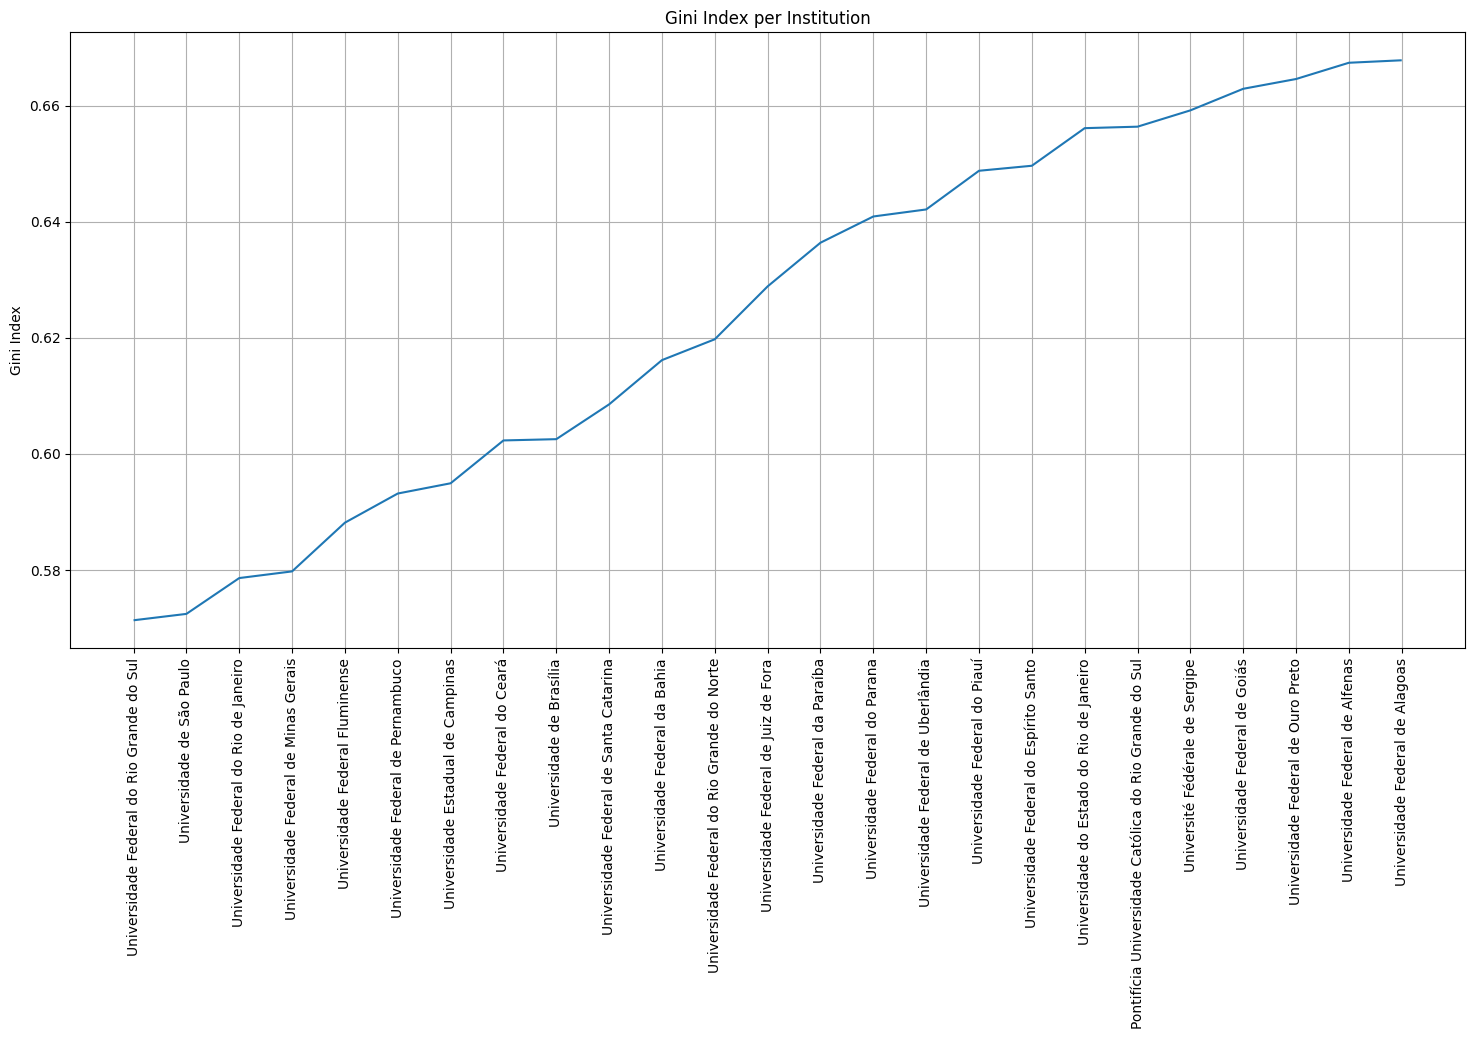

In [25]:
plt.figure(figsize=(18, 8))
plt.plot(di_table_subs['ins_name'].head(25), di_table_subs['gini_index'].head(25), linestyle=(0, (1, 0)))
plt.xticks(rotation=90, fontsize=10)  # rotate + smaller font
plt.ylabel('Gini Index')
plt.title('Gini Index per Institution')
plt.grid(True)
plt.show()



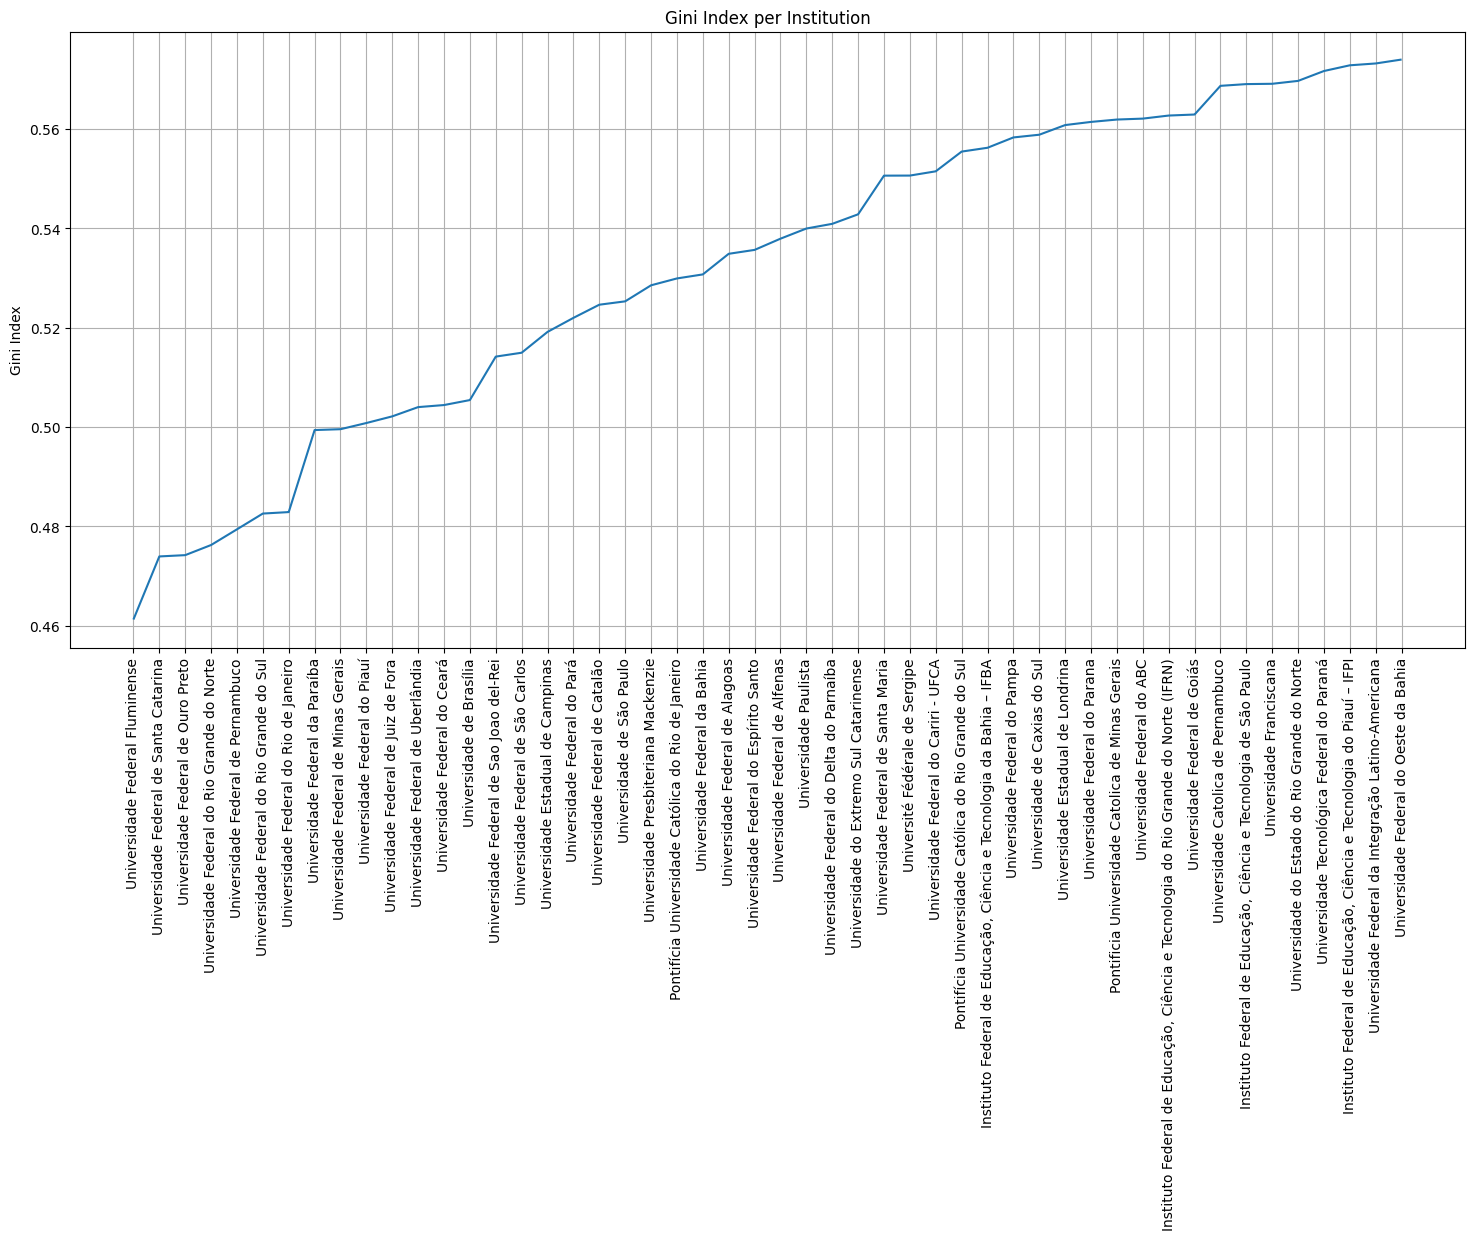

In [26]:
plt.figure(figsize=(18, 8))
plt.plot(di_table_macros['ins_name'].head(50), di_table_macros['gini_index'].head(50), linestyle=(0, (1, 0)))
plt.xticks(rotation=90, fontsize=10)  # rotate + smaller font
plt.ylabel('Gini Index')
plt.title('Gini Index per Institution')
plt.grid(True)
plt.show()

In [27]:
di_table_subs.head()

,ins_name,Accounting,Acoustics and Ultrasonics,Advanced and Specialized Nursing,Aerospace Engineering,Aging,Agricultural and Biological Sciences (miscellaneous),Agronomy and Crop Science,Algebra and Number Theory,Analysis,...,Transplantation,Transportation,Urban Studies,Urology,Veterinary (miscellaneous),Virology,Visual Arts and Performing Arts,Waste Management and Disposal,Water Science and Technology,gini_index
19,Universidade Federal do Rio Grande do Sul,19.891733,6.494048,24.952092,29.832103,15.010453,30.648410,321.025561,39.206944,24.288889,...,19.285642,18.939683,27.123533,23.871693,10.497132,59.616734,40.401389,102.312347,168.724754,0.571343
0,Universidade de São Paulo,76.715512,50.972030,116.697536,112.910437,71.094912,163.182917,1093.839734,213.788889,243.996465,...,146.951700,59.560119,95.181238,300.493597,37.407609,259.908087,110.006667,349.917220,302.910083,0.572443
7,Universidade Federal do Rio de Janeiro,15.688690,29.698776,25.952107,49.166389,10.414841,40.369400,86.432812,51.041667,68.600794,...,12.194213,30.114683,54.783929,9.303505,1.970040,72.057737,38.610714,117.998005,113.584566,0.578615
3,Universidade Federal de Minas Gerais,14.562500,12.134524,21.917560,29.601032,12.316456,40.399462,141.179496,65.769444,45.555556,...,19.014326,13.401677,36.599738,30.777787,45.332705,99.123394,41.942063,142.902861,139.580537,0.579763
1,Universidade Federal Fluminense,4.530952,3.944147,14.768098,9.496055,1.735570,12.808184,42.664545,24.812500,38.290278,...,2.676340,8.532143,15.422143,15.200977,3.444444,11.001322,18.190079,28.369088,32.355018,0.588155


In [28]:
di_table_macros.head(20)

,ins_name,AGRI,ARTS,BIOC,BUSI,CHEM,COMP,DECI,DENT,EART,...,MEDI,MULT,NEUR,NURS,PHAR,PHYS,PSYC,SOCI,VETE,gini_index
1,Universidade Federal Fluminense,624.653402,445.172692,283.289645,172.238044,375.678541,325.553361,113.064173,106.701623,379.653925,...,1229.296624,176.582491,82.063439,98.785937,109.191527,708.518925,48.201030,914.860595,57.470703,0.461236
21,Universidade Federal de Santa Catarina,1965.452409,544.088624,621.761720,307.325511,789.921054,497.566159,92.260073,112.290212,286.895354,...,1650.749317,283.200770,205.222948,336.218396,327.265862,708.451404,136.075176,1687.011142,24.991479,0.473941
38,Universidade Federal de Ouro Preto,231.123092,88.367492,121.327790,34.983889,159.783116,70.425327,35.884841,0.166667,286.296715,...,282.685228,81.450625,15.986951,37.159169,83.053210,111.605816,8.791989,201.858940,2.224751,0.474202
52,Universidade Federal do Rio Grande do Norte,833.765531,159.790920,330.253143,52.679067,413.237970,258.755691,42.472520,87.943530,554.665057,...,1264.979276,419.088539,139.087782,139.466626,165.092612,760.317731,95.028947,563.063278,8.923683,0.476240
5,Universidade Federal de Pernambuco,1409.073333,185.765776,518.846657,188.357606,386.956181,566.308678,132.480714,30.301518,570.936458,...,1445.425927,297.473615,104.492307,151.166257,219.543101,549.375499,65.892398,832.093443,5.140276,0.479400
19,Universidade Federal do Rio Grande do Sul,2668.367326,483.941902,1389.423608,318.303631,865.722209,590.625716,105.126288,145.038305,1156.762834,...,3714.161429,652.284220,480.097773,263.382669,465.849982,1052.069595,280.796647,1746.565761,108.916073,0.482576
7,Universidade Federal do Rio de Janeiro,2456.376384,709.968257,1561.050035,272.905530,1347.986204,595.317322,142.610973,156.884797,1131.233177,...,3796.672928,847.422128,286.330852,225.319492,451.208356,1833.660406,141.859870,1926.240112,6.963727,0.482872
23,Universidade Federal da Paraíba,1241.135330,134.760270,265.584201,93.692440,342.306609,120.934148,36.855317,49.021825,142.954541,...,694.476097,144.575248,40.149666,88.944377,153.709686,531.098502,110.256993,585.795441,28.099739,0.499390
3,Universidade Federal de Minas Gerais,2004.663618,623.489581,1207.090249,168.385451,792.504666,628.216343,113.100724,192.629241,438.682711,...,4813.881079,691.687689,293.239976,237.788060,518.799766,659.978066,190.640775,1809.492758,123.526799,0.499563
17,Universidade Federal do Piauí,577.588217,76.904394,144.171523,13.135209,136.139428,156.170628,15.979762,18.257540,75.708485,...,353.931659,75.525603,12.377656,96.224687,121.128693,124.363429,16.660065,158.567751,19.615759,0.500808


In [29]:
"""di_table_macros.head()
final_leys_macros = di_table_macros.drop(columns=['gini_index', 'ins_name']).to_csv('teste.csv', header = None, index=False)
final_leys_macros = pd.read_csv('teste.csv', header=None)
final_leys_macros.to_csv('leys_macros.csv', index=False, header=False)
final_leys_subs = di_table_subs.drop(columns=['gini_index','ins_name']).T.to_csv('leys_subs.csv', index=True)
"""

"di_table_macros.head()\nfinal_leys_macros = di_table_macros.drop(columns=['gini_index', 'ins_name']).to_csv('teste.csv', header = None, index=False)\nfinal_leys_macros = pd.read_csv('teste.csv', header=None)\nfinal_leys_macros.to_csv('leys_macros.csv', index=False, header=False)\nfinal_leys_subs = di_table_subs.drop(columns=['gini_index','ins_name']).T.to_csv('leys_subs.csv', index=True)\n"

In [ ]:
di_table_macros.head()
final_leys_macros = di_table_macros.drop(columns=['gini_index', 'ins_name']).T.to_csv('leys_macros.csv', index=False, header=False)
final_leys_subs = di_table_subs.drop(columns=['gini_index', 'ins_name']).T.to_csv('leys_subs.csv', index=False, header=False)
